In [1]:
import numpy as np
import networkx as nx
from scipy.spatial import cKDTree, distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.optimize import least_squares
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class VascularTreeReconstruction:
    """
    Reconstruct vascular tree from skeleton points using CCO principles
    """
    def __init__(self, skeleton_points, gamma=3.0, mu=3.6e-3, 
                 Q_perf=0.125, P_out=60, P_in=100):
        """
        Parameters:
        -----------
        skeleton_points : np.array, shape (N, 3)
            3D coordinates of skeleton points
        gamma : float
            Murray's law exponent (default: 3.0)
        mu : float
            Blood viscosity in Pa·s (default: 3.6e-3 Pa·s = 3.6 cP)
        Q_perf : float
            Flow at each terminal in mL/min (default: 0.125)
        P_out : float
            Pressure at terminals in mmHg (default: 60)
        P_in : float
            Pressure at root in mmHg (default: 100)
        """
        self.points = np.array(skeleton_points)
        self.gamma = gamma
        self.mu = mu
        self.Q_perf = Q_perf / 60000  # Convert mL/min to mm³/s
        self.P_out = P_out * 133.322  # Convert mmHg to Pa
        self.P_in = P_in * 133.322
        self.kappa = 8 * mu / np.pi
        self.xi = self.Q_perf / (self.P_in - self.P_out)
        
        self.graph = None
        self.root = None
        self.tree_structure = None
        
    def build_graph_from_skeleton(self, k_neighbors=10, max_edge_length=None):
        """
        Step 1-2: Build connected graph from skeleton points
        Uses k-nearest neighbors + MST to ensure connectivity
        
        Parameters:
        -----------
        k_neighbors : int
            Number of nearest neighbors to consider
        max_edge_length : float
            Maximum allowed edge length (for pruning)
        """
        print("Building graph from skeleton points...")
        n_points = len(self.points)
        
        # Build k-NN graph
        tree = cKDTree(self.points)
        
        # Create adjacency matrix
        distances = np.zeros((n_points, n_points))
        distances[:] = np.inf
        
        for i in range(n_points):
            dists, indices = tree.query(self.points[i], k=min(k_neighbors+1, n_points))
            for j, idx in enumerate(indices[1:]):  # Skip self
                distances[i, idx] = dists[j+1]
                distances[idx, i] = dists[j+1]  # Symmetric
        
        # Build MST to ensure single connected component and remove cycles
        mst = minimum_spanning_tree(distances)
        
        # Convert to networkx graph
        self.graph = nx.Graph()
        
        # Add nodes with positions
        for i, pos in enumerate(self.points):
            self.graph.add_node(i, pos=pos)
        
        # Add edges from MST
        mst_coo = mst.tocoo()
        for i, j, weight in zip(mst_coo.row, mst_coo.col, mst_coo.data):
            self.graph.add_edge(i, j, length=weight)
        
        print(f"Graph built: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")
        
        # Prune short branches
        if max_edge_length:
            self._prune_branches(max_edge_length)
        
        return self.graph
    
    def _prune_branches(self, min_length):
        """Remove short terminal branches"""
        pruned = True
        while pruned:
            pruned = False
            endpoints = [n for n in self.graph.nodes() if self.graph.degree(n) == 1]
            
            for node in endpoints:
                neighbor = list(self.graph.neighbors(node))[0]
                edge_length = self.graph[node][neighbor]['length']
                
                if edge_length < min_length:
                    self.graph.remove_node(node)
                    pruned = True
        
        print(f"After pruning: {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges")
    
    def find_root_candidates(self, n_candidates=5):
        """
        Step 4: Identify potential root points
        
        Returns candidates based on:
        - Boundary points (degree 1)
        - Spatial location (e.g., superior, medial)
        - High centrality
        """
        candidates = []
        
        # Get all endpoints (degree 1)
        endpoints = [n for n in self.graph.nodes() if self.graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            print("Warning: No endpoints found, using highest degree nodes")
            degrees = dict(self.graph.degree())
            endpoints = sorted(degrees, key=degrees.get, reverse=True)[:10]
        
        endpoint_positions = np.array([self.points[i] for i in endpoints])
        
        # Strategy 1: Highest z-coordinate (superior position for hepatic vein)
        z_coords = endpoint_positions[:, 2]
        top_z_indices = np.argsort(z_coords)[-n_candidates:]
        candidates.extend([endpoints[i] for i in top_z_indices])

        print(f"Found {len(candidates)} candidates from superior endpoints")
        
        # Strategy 2: Most central points (low eccentricity)
        if len(self.graph) > 10:
            try:
                # Get largest connected component
                if not nx.is_connected(self.graph):
                    largest_cc = max(nx.connected_components(self.graph), key=len)
                    subgraph = self.graph.subgraph(largest_cc)
                else:
                    subgraph = self.graph
                
                centrality = nx.closeness_centrality(subgraph)
                central_nodes = sorted(centrality, key=centrality.get, reverse=True)[:n_candidates]
                candidates.extend([n for n in central_nodes if n in endpoints])
            except:
                pass
        
        # Remove duplicates while preserving order
        seen = set()
        unique_candidates = []
        for c in candidates:
            if c not in seen:
                seen.add(c)
                unique_candidates.append(c)
        
        print(f"Found {len(unique_candidates)} root candidates")
        return unique_candidates[:n_candidates]
    
    def orient_tree_from_root(self, root):
        """
        Step 5a: Create directed tree structure from root
        Returns tree with parent-child relationships
        """
        if not nx.is_connected(self.graph):
            # Get largest connected component containing root
            for component in nx.connected_components(self.graph):
                if root in component:
                    subgraph = self.graph.subgraph(component).copy()
                    break
        else:
            subgraph = self.graph
        
        # BFS from root to create directed tree
        tree = nx.DiGraph()
        visited = {root}
        queue = [root]
        
        # Copy node attributes
        for node in subgraph.nodes():
            tree.add_node(node, pos=self.points[node])
        
        while queue:
            current = queue.pop(0)
            
            for neighbor in subgraph.neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    # Add directed edge from parent to child
                    edge_data = subgraph[current][neighbor]
                    tree.add_edge(current, neighbor, **edge_data)
                    queue.append(neighbor)
        
        return tree
    
    def compute_tree_parameters(self, tree, root):
        """
        Step 5b: Compute L_i (number of terminals in subtree)
        """
        # Find all terminal nodes (leaves)
        terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0 and n != root]
        
        # Compute L_i for each node (number of terminals in subtree)
        L = {}
        
        def count_terminals(node):
            if tree.out_degree(node) == 0:  # Terminal
                L[node] = 1
                return 1
            
            total = 0
            for child in tree.successors(node):
                total += count_terminals(child)
            L[node] = total
            return total
        
        count_terminals(root)
        
        return L, terminals
    
    def compute_radii(self, tree, root, L):
        """
        Step 5c: Apply CCO radius formulas (Equations 1-7)
        """
        # Initialize radius dict
        R = {}  # Hydraulic resistance
        beta = {}  # Radius ratio to parent
        rho = {}  # Relative radius to root segment
        radii = {}  # Actual radii
        
        # Compute resistance R and beta bottom-up
        def compute_resistance(node):
            children = list(tree.successors(node))
            
            if len(children) == 0:  # Terminal node
                # For terminal: R = kappa * length / r^4
                # We'll initialize with a default and iterate
                R[node] = 1.0  # Will be updated
                return R[node]
            
            # Get edge length to parent
            parent = list(tree.predecessors(node))
            if parent:
                length = tree[parent[0]][node]['length']
            else:  # Root
                # Estimate length from first child
                if children:
                    length = tree[node][children[0]]['length']
                else:
                    length = 1.0
            
            # Compute children resistances first (bottom-up)
            child_resistances = []
            for child in children:
                child_resistances.append(compute_resistance(child))
            
            # Compute beta for each child (Equations 3-4)
            if len(children) == 2:
                child1, child2 = children
                
                # Alpha ratio (Eq. 4)
                alpha = ((L[child1] / L[node]) * 
                        (R[child1] / R[child2])) ** 0.25
                
                # Beta for each child (Eq. 3)
                beta[child1] = (1 + alpha ** self.gamma) ** (-1/self.gamma)
                beta[child2] = (1 + (1/alpha) ** self.gamma) ** (-1/self.gamma)
            else:
                # Single child or more than 2 children
                for child in children:
                    beta[child] = 1.0
            
            # Compute resistance (Eq. 6)
            sum_term = sum(beta[child]**4 / R[child] for child in children)
            if sum_term > 0:
                R[node] = self.kappa * length + (1 / sum_term)
            else:
                R[node] = self.kappa * length
            
            return R[node]
        
        # Start computation from root
        compute_resistance(root)
        
        # Compute absolute radii top-down (Eq. 7)
        def compute_radii_recursive(node, parent_radius=None):
            if parent_radius is None:
                # Root radius (Eq. 7)
                n_terminals = L[root]
                r1 = (self.xi * R[root] * n_terminals) ** 0.25
                radii[node] = r1
                rho[node] = 1.0
            else:
                # Child radius
                rho[node] = rho[list(tree.predecessors(node))[0]] * beta[node]
                radii[node] = parent_radius * beta[node]
            
            # Recurse to children
            for child in tree.successors(node):
                compute_radii_recursive(child, radii[node])
        
        compute_radii_recursive(root)
        
        return radii, R, beta, rho
    
    def optimize_bifurcation(self, tree, node, radii):
        """
        Step 5d: Kamiya optimization for bifurcation point
        
        Optimizes the position of a bifurcation node to minimize total volume
        """
        # Check if this is a bifurcation
        children = list(tree.successors(node))
        parents = list(tree.predecessors(node))
        
        if len(children) != 2 or len(parents) != 1:
            return  # Not a bifurcation or is root
        
        parent = parents[0]
        child1, child2 = children
        
        # Get positions
        p_parent = self.points[parent]
        p_child1 = self.points[child1]
        p_child2 = self.points[child2]
        p_current = self.points[node]
        
        # Get radii
        r0 = radii[node]  # Parent segment
        r1 = radii[child1]
        r2 = radii[child2]
        
        # Flow ratios (proportional to L_i)
        f0 = 1.0  # Normalized
        f1 = r1**3  # From Eq. 10: fi ∝ ri³
        f2 = r2**3
        
        def objective(x):
            """
            Optimize bifurcation position using Kamiya method
            Based on Equations 9-13 from the paper
            """
            # x is the new position of the bifurcation node
            if len(x) == 2:
                p_bif = np.array([x[0], x[1], p_current[2]])  # 2D
            else:
                p_bif = x
            
            # Compute lengths
            l0 = np.linalg.norm(p_bif - p_parent)
            l1 = np.linalg.norm(p_child1 - p_bif)
            l2 = np.linalg.norm(p_child2 - p_bif)
            
            if l0 < 1e-6 or l1 < 1e-6 or l2 < 1e-6:
                return np.array([1e10, 1e10])
            
            # Pressure drop equations (Eq. 9)
            delta1 = f0 * l0 / r0**4 + f1 * l1 / r1**4
            delta2 = f0 * l0 / r0**4 + f2 * l2 / r2**4
            
            # Murray's law constraint (Eq. 11)
            r0_expected = (f0 * (r1**6/f1 + r2**6/f2))**(1/3)
            
            # Residuals (Eq. 12)
            residual1 = delta1 * r1**4 - f0 * l0 * r1**4 / r0**4 - f1 * l1
            residual2 = delta2 * r2**4 - f0 * l0 * r2**4 / r0**4 - f2 * l2
            
            return np.array([residual1, residual2])
        
        # Initial guess: current position
        x0 = p_current[:2] if len(p_current) == 3 else p_current
        
        # Bounds: stay within triangle formed by parent and children
        try:
            result = least_squares(objective, x0, method='lm', max_nfev=100)
            
            if result.success:
                # Update position
                if len(p_current) == 3:
                    new_pos = np.array([result.x[0], result.x[1], p_current[2]])
                else:
                    new_pos = result.x
                
                # Check if new position is reasonable (within triangle + margin)
                max_dist = max(np.linalg.norm(p_parent - p_current),
                              np.linalg.norm(p_child1 - p_current),
                              np.linalg.norm(p_child2 - p_current))
                
                if np.linalg.norm(new_pos - p_current) < 2 * max_dist:
                    self.points[node] = new_pos
                    tree.nodes[node]['pos'] = new_pos
                    
                    # Update edge lengths
                    tree[parent][node]['length'] = np.linalg.norm(new_pos - p_parent)
                    tree[node][child1]['length'] = np.linalg.norm(p_child1 - new_pos)
                    tree[node][child2]['length'] = np.linalg.norm(p_child2 - new_pos)
        except:
            pass  # Keep original position if optimization fails
    
    def compute_quality_metrics(self, tree, root, radii, L):
        """
        Step 6: Compute quality metrics for tree evaluation
        """
        metrics = {}
        
        # 1. Total volume
        total_volume = 0
        for u, v in tree.edges():
            length = tree[u][v]['length']
            radius = radii[v]  # Child radius
            volume = np.pi * radius**2 * length
            total_volume += volume
        
        metrics['total_volume'] = total_volume
        
        # 2. Check monotonic radius decrease
        radius_violations = 0
        for node in tree.nodes():
            if node == root:
                continue
            parent = list(tree.predecessors(node))[0]
            if radii[node] > radii[parent]:
                radius_violations += 1
        
        metrics['radius_violations'] = radius_violations
        
        # 3. Murray's law compliance at bifurcations
        murray_errors = []
        for node in tree.nodes():
            children = list(tree.successors(node))
            if len(children) == 2:
                r_parent = radii[node]
                r_child1 = radii[children[0]]
                r_child2 = radii[children[1]]
                
                # Murray's law: r0^γ = r1^γ + r2^γ
                expected = (r_child1**self.gamma + r_child2**self.gamma)**(1/self.gamma)
                error = abs(r_parent - expected) / r_parent
                murray_errors.append(error)
        
        metrics['murray_error_mean'] = np.mean(murray_errors) if murray_errors else 0
        metrics['murray_error_max'] = np.max(murray_errors) if murray_errors else 0
        
        # 4. Geometric quality - bifurcation angles
        angles = []
        for node in tree.nodes():
            children = list(tree.successors(node))
            if len(children) == 2:
                pos = self.points[node]
                pos1 = self.points[children[0]]
                pos2 = self.points[children[1]]
                
                v1 = pos1 - pos
                v2 = pos2 - pos
                
                cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
                angle = np.arccos(np.clip(cos_angle, -1, 1)) * 180 / np.pi
                angles.append(angle)
        
        metrics['mean_bifurcation_angle'] = np.mean(angles) if angles else 0
        metrics['min_bifurcation_angle'] = np.min(angles) if angles else 0
        
        # 5. Root quality - prefer anatomically superior position
        root_z = self.points[root][2] if len(self.points[root]) == 3 else 0
        max_z = np.max(self.points[:, 2]) if len(self.points[0]) == 3 else 1
        metrics['root_z_score'] = root_z / (max_z + 1e-10)
        
        return metrics
    
    def reconstruct(self, k_neighbors=10, n_candidates=5, optimize_bifurcations=True):
        """
        Main reconstruction pipeline
        
        Returns:
        --------
        best_tree : networkx.DiGraph
            The best reconstructed tree
        best_root : int
            Index of the best root node
        best_radii : dict
            Radius for each segment
        metrics : dict
            Quality metrics
        """
        # Step 1-2: Build graph
        if self.graph is None:
            self.build_graph_from_skeleton(k_neighbors=k_neighbors)
        
        # Step 3: Terminal points (already identified in graph structure)
        
        # Step 4: Find root candidates
        candidates = self.find_root_candidates(n_candidates=n_candidates)
        
        print(f"\nEvaluating {len(candidates)} root candidates...")
        
        best_score = float('inf')
        best_tree = None
        best_root = None
        best_radii = None
        best_metrics = None
        
        for i, root in enumerate(candidates):
            print(f"\nCandidate {i+1}/{len(candidates)}: node {root}")
            
            try:
                # Step 5a: Orient tree from this root
                tree = self.orient_tree_from_root(root)
                
                # Step 5b: Compute L_i
                L, terminals = self.compute_tree_parameters(tree, root)
                print(f"  Terminals: {len(terminals)}, Total nodes: {tree.number_of_nodes()}")
                
                # Step 5c: Compute radii
                radii, R, beta, rho = self.compute_radii(tree, root, L)
                
                # Step 5d: Optimize bifurcations (optional)
                if optimize_bifurcations:
                    bifurcations = [n for n in tree.nodes() 
                                   if tree.out_degree(n) == 2 and tree.in_degree(n) == 1]
                    print(f"  Optimizing {len(bifurcations)} bifurcations...")
                    for bif in bifurcations[:min(10, len(bifurcations))]:  # Limit for speed
                        self.optimize_bifurcation(tree, bif, radii)
                    
                    # Recompute radii after optimization
                    radii, R, beta, rho = self.compute_radii(tree, root, L)
                
                # Step 6: Evaluate quality
                metrics = self.compute_quality_metrics(tree, root, radii, L)
                
                print(f"  Metrics: volume={metrics['total_volume']:.2f}, "
                      f"murray_error={metrics['murray_error_mean']:.4f}, "
                      f"radius_violations={metrics['radius_violations']}")
                
                # Scoring: lower is better
                score = (metrics['total_volume'] / 1000 +  # Normalize volume
                        metrics['murray_error_mean'] * 100 +
                        metrics['radius_violations'] * 10 -
                        metrics['root_z_score'] * 50)  # Prefer higher roots
                
                if score < best_score:
                    best_score = score
                    best_tree = tree
                    best_root = root
                    best_radii = radii
                    best_metrics = metrics
                    
            except Exception as e:
                print(f"  Failed: {e}")
                continue
        
        if best_tree is None:
            raise RuntimeError("No valid tree found from any root candidate")
        
        print(f"\n=== Best tree (root={best_root}) ===")
        for k, v in best_metrics.items():
            print(f"  {k}: {v}")
        
        self.tree_structure = {
            'tree': best_tree,
            'root': best_root,
            'radii': best_radii,
            'metrics': best_metrics
        }
        
        return best_tree, best_root, best_radii, best_metrics
    
    def visualize_tree(self, tree=None, root=None, radii=None, show_radii=True):
        """
        Visualize the reconstructed tree
        """
        if tree is None:
            tree = self.tree_structure['tree']
            root = self.tree_structure['root']
            radii = self.tree_structure['radii']
        
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Draw edges
        for u, v in tree.edges():
            pos_u = self.points[u]
            pos_v = self.points[v]
            
            if show_radii and radii:
                # Line width proportional to radius
                radius = radii[v]
                linewidth = max(0.5, min(5, radius * 10))  # Scale for visibility
                color = plt.cm.RdYlBu_r(radius / max(radii.values()))
            else:
                linewidth = 1
                color = 'blue'
            
            ax.plot([pos_u[0], pos_v[0]], 
                   [pos_u[1], pos_v[1]], 
                   [pos_u[2], pos_v[2]], 
                   'b-', linewidth=linewidth, color=color, alpha=0.6)
        
        # Highlight root
        root_pos = self.points[root]
        ax.scatter(*root_pos, c='red', s=100, marker='o', label='Root')
        
        # Highlight terminals
        terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
        terminal_pos = self.points[terminals]
        ax.scatter(terminal_pos[:, 0], terminal_pos[:, 1], terminal_pos[:, 2], 
                  c='green', s=20, marker='^', label='Terminals', alpha=0.5)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend()
        ax.set_title('Reconstructed Vascular Tree')
        
        plt.tight_layout()
        return fig, ax
    
    def export_tree(self, filename, tree=None, radii=None):
        """
        Export tree to file format (e.g., for visualization or further processing)
        """
        if tree is None:
            tree = self.tree_structure['tree']
            radii = self.tree_structure['radii']
        
        with open(filename, 'w') as f:
            f.write("# Vascular Tree Structure\n")
            f.write("# Format: node_id parent_id x y z radius\n")
            
            root = self.tree_structure['root']
            f.write(f"{root} -1 {' '.join(map(str, self.points[root]))} {radii[root]:.6f}\n")
            
            for node in nx.dfs_preorder_nodes(tree, root):
                if node == root:
                    continue
                parent = list(tree.predecessors(node))[0]
                pos = self.points[node]
                radius = radii[node]
                f.write(f"{node} {parent} {' '.join(map(str, pos))} {radius:.6f}\n")
        
        print(f"Tree exported to {filename}")

    def export_tree_for_viewer(self, filename, tree=None, radii=None):
        """
        Export tree to JSON format compatible with the multi-volume viewer
        
        Format expected by viewer:
        [
        {
            "start": [x1, y1, z1],
            "end": [x2, y2, z2],
            "radius": 1.2,
            "Q": 5
        },
        ...
        ]
        
        Parameters:
        -----------
        filename : str
            Output JSON filename
        tree : networkx.DiGraph (optional)
            Tree to export (uses self.tree_structure if None)
        radii : dict (optional)
            Radii for each node (uses self.tree_structure if None)
        """
        import json
        
        if tree is None:
            tree = self.tree_structure['tree']
            radii = self.tree_structure['radii']
            root = self.tree_structure['root']
        
        branches = []
        
        # Iterate through all edges in the tree
        for parent, child in tree.edges():
            # Get positions
            start_pos = self.points[parent].tolist()
            end_pos = self.points[child].tolist()
            
            # Get radius (use child's radius for the segment)
            radius = float(radii[child])
            
            # Compute flow Q (proportional to r³ from Equation 10)
            # Scale to reasonable values (relative flow)
            Q = float(radius ** 3 * 100)  # Scale factor for visualization
            
            branch = {
                "start": start_pos,
                "end": end_pos,
                "radius": radius,
                "Q": Q
            }
            
            branches.append(branch)
        
        # Write to JSON file
        with open(filename, 'w') as f:
            json.dump(branches, f, indent=2)
        
        print(f"Tree exported to {filename} ({len(branches)} branches)")
        print(f"Radius range: [{min(b['radius'] for b in branches):.4f}, {max(b['radius'] for b in branches):.4f}]")


# Example usage
def example_usage():
    """
    Example: Generate synthetic skeleton points and reconstruct tree
    """
    # Simulate skeleton points (replace with your actual skeleton data)
    np.random.seed(42)
    
    # Create a synthetic branching structure
    n_points = 200
    skeleton_points = []
    
    # Main trunk
    for i in range(50):
        skeleton_points.append([0, 0, i])
    
    # Branch 1
    for i in range(30):
        skeleton_points.append([i*0.5, i*0.3, 50 + i*0.5])
    
    # Branch 2
    for i in range(30):
        skeleton_points.append([-i*0.5, i*0.3, 50 + i*0.5])
    
    # Add some noise and sub-branches
    for _ in range(90):
        base = skeleton_points[np.random.randint(0, len(skeleton_points))]
        offset = np.random.randn(3) * 5
        skeleton_points.append(base + offset)
    
    skeleton_points = np.array(skeleton_points)
    
    # Initialize reconstructor
    reconstructor = VascularTreeReconstruction(
        skeleton_points,
        gamma=3.0,
        mu=3.6e-3,
        Q_perf=0.125,
        P_out=60,
        P_in=100
    )
    
    # Run reconstruction
    tree, root, radii, metrics = reconstructor.reconstruct(
        k_neighbors=8,
        n_candidates=500,
        optimize_bifurcations=True
    )
    
    # Visualize
    fig, ax = reconstructor.visualize_tree()
    plt.show()
    
    # Export
    reconstructor.export_tree('vascular_tree.txt')
    
    return reconstructor, tree, radii, metrics


# if __name__ == "__main__":
#     print("Starting vascular tree reconstruction example...")
#     reconstructor, tree, radii, metrics = example_usage()

In [2]:
import sys 
sys.path.append("../metric-test")
import metrics as sm
import get_skeleton as gs
from skimage.morphology import skeletonize
import nibabel as nib
import json

seg_path = "../data/VenaHepatica_merged_fill.nii.gz"
seg, _ = sm.load_nii(seg_path)
# thinning = gs.get_skeleton(path, "thinning")
# thinning = skeletonize(seg)
# sm.save_skeleton(thinning, "../data/VenaHepatica_thinning0.json")

def load_thinning(labels):
    skeleton = skeletonize(labels)
    skeleton_points = np.array(np.where(skeleton)).T
    return skeleton_points

def save_skeleton(skeleton_points, filename):
    # Ensure a pure Python list is saved (JSON cannot serialize numpy arrays)
    to_save = np.array(skeleton_points).tolist()
    with open(filename, 'w') as f:
        json.dump(to_save, f)
    print(f"Skeleton saved to {filename}")

thinning = load_thinning(seg)
save_skeleton(thinning, "../data/VenaHepatica_thinning.json")

Skeleton saved to ../data/VenaHepatica_thinning.json


In [3]:
# Initialize reconstructor
reconstructor = VascularTreeReconstruction(
    thinning,
    gamma=3.0,
    mu=3.6e-3,
    Q_perf=0.125,
    P_out=60,
    P_in=100
)

# Run reconstruction
tree, root, radii, metrics = reconstructor.reconstruct(
    k_neighbors=8,
    n_candidates=500,
    optimize_bifurcations=True
)

# Visualize
# fig, ax = reconstructor.visualize_tree()
# plt.show()

reconstructor.export_tree_for_viewer('hepatic_vein_tree2.json')
print(tree)

Building graph from skeleton points...
Graph built: 1305 nodes, 1303 edges
Found 43 candidates from superior endpoints
Found 43 root candidates

Evaluating 43 root candidates...

Candidate 1/43: node 1292
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.09, murray_error=0.0000, radius_violations=0

Candidate 2/43: node 1264
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.03, murray_error=0.0000, radius_violations=0

Candidate 3/43: node 1218
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.07, murray_error=0.0000, radius_violations=0

Candidate 4/43: node 222
  Terminals: 20, Total nodes: 635
  Optimizing 19 bifurcations...
  Metrics: volume=0.04, murray_error=0.0000, radius_violations=0

Candidate 5/43: node 1165
  Terminals: 20, Total nodes: 635
  Optimizing 19 bifurcations...
  Metrics: volume=0.05, murray_error=0.0000, radius_violations=0

Candidate 6/43: node 1056
  Term

/var/folders/26/f0r1bgyd67738k064bnrh4v40000gn/T/ipykernel_16477/1052430445.py:601: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot([pos_u[0], pos_v[0]],


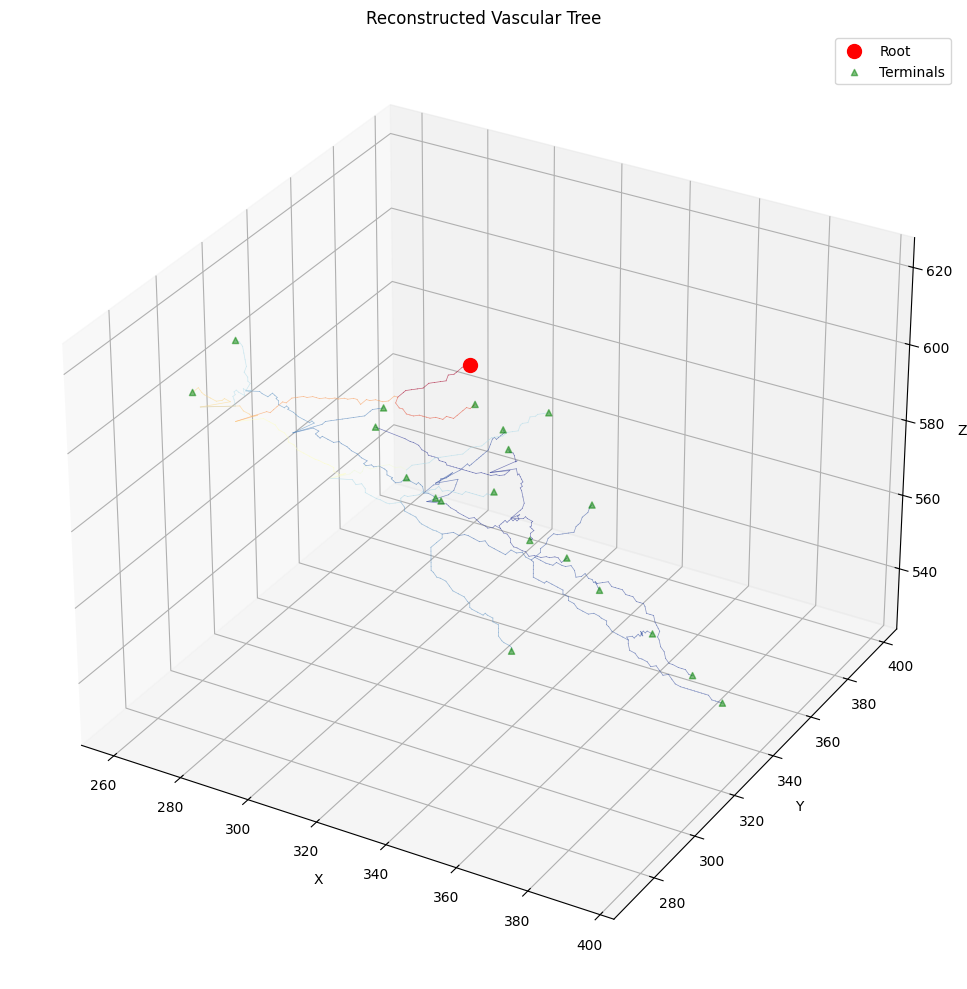

In [4]:
# Visualize
fig, ax = reconstructor.visualize_tree()
plt.show()

In [5]:
class MultiTreeReconstruction:
    """
    Reconstruct multiple independent vascular trees from a single point cloud
    """
    def __init__(self, skeleton_points, n_trees=3, gamma=3.0, mu=3.6e-3, 
                 Q_perf=0.125, P_out=60, P_in=100):
        """
        Parameters:
        -----------
        skeleton_points : np.array, shape (N, 3)
            3D coordinates of skeleton points
        n_trees : int
            Expected number of separate trees to extract
        gamma, mu, Q_perf, P_out, P_in : float
            CCO physiological parameters (same as VascularTreeReconstruction)
        """
        self.original_points = np.array(skeleton_points)
        self.n_trees = n_trees
        self.gamma = gamma
        self.mu = mu
        self.Q_perf = Q_perf
        self.P_out = P_out
        self.P_in = P_in
        
        self.trees = []  # List of reconstructed trees
        self.remaining_points = self.original_points.copy()
        self.point_to_tree_mapping = {}  # Maps original point index to tree index
        
    def reconstruct_multiple_trees(self, k_neighbors_initial=5, k_neighbors_optimization=10,
                                   min_tree_size=50, max_iterations=10):
        """
        Extract multiple trees iteratively
        
        Parameters:
        -----------
        k_neighbors_initial : int
            Low k for initial sparse connectivity (helps separate trees)
        k_neighbors_optimization : int
            Higher k for optimizing individual trees
        min_tree_size : int
            Minimum number of points required for a valid tree
        max_iterations : int
            Maximum number of trees to extract
        
        Returns:
        --------
        trees : list of dict
            List of tree structures, each containing:
            - 'tree': networkx.DiGraph
            - 'root': int (root node in original point indexing)
            - 'radii': dict
            - 'metrics': dict
            - 'points': np.array (points for this tree)
            - 'point_indices': list (indices in original point cloud)
        """
        print(f"Starting multi-tree reconstruction from {len(self.original_points)} points")
        print(f"Target: {self.n_trees} trees\n")
        
        iteration = 0
        
        while len(self.remaining_points) >= min_tree_size and iteration < max_iterations:
            iteration += 1
            print(f"{'='*60}")
            print(f"ITERATION {iteration}: {len(self.remaining_points)} points remaining")
            print(f"{'='*60}\n")
            
            # Extract one tree from remaining points
            tree_data = self._extract_single_tree(
                k_neighbors_initial=k_neighbors_initial,
                k_neighbors_optimization=k_neighbors_optimization,
                min_tree_size=min_tree_size
            )
            
            if tree_data is None:
                print("No more valid trees found. Stopping.")
                break
            
            self.trees.append(tree_data)
            
            # Remove points belonging to this tree
            self._remove_tree_points(tree_data)
            
            print(f"\n✓ Tree {iteration} extracted: {len(tree_data['point_indices'])} points")
            print(f"  Root at: {tree_data['points'][tree_data['root']]}")
            print(f"  Terminals: {len([n for n in tree_data['tree'].nodes() if tree_data['tree'].out_degree(n) == 0])}")
            print(f"  Total volume: {tree_data['metrics']['total_volume']:.2f} mm³")
            print(f"  Remaining points: {len(self.remaining_points)}\n")
            
            # Stop if we've extracted enough trees
            if len(self.trees) >= self.n_trees:
                print(f"Extracted target number of trees ({self.n_trees}). Stopping.")
                break
        
        print(f"\n{'='*60}")
        print(f"FINAL RESULT: {len(self.trees)} trees extracted")
        print(f"{'='*60}")
        
        for i, tree_data in enumerate(self.trees):
            print(f"Tree {i+1}: {len(tree_data['point_indices'])} points, "
                  f"volume={tree_data['metrics']['total_volume']:.2f} mm³")
        
        if len(self.remaining_points) > 0:
            print(f"\nWarning: {len(self.remaining_points)} points not assigned to any tree")
        
        return self.trees
    
    def _extract_single_tree(self, k_neighbors_initial, k_neighbors_optimization, min_tree_size):
        """
        Extract one tree from remaining points using sparse connectivity
        """
        if len(self.remaining_points) < min_tree_size:
            return None
        
        # Step 1: Build sparse graph to identify connected components
        print(f"Step 1: Building sparse graph (k={k_neighbors_initial})...")
        sparse_graph = self._build_sparse_graph(self.remaining_points, k_neighbors_initial)
        
        if sparse_graph.number_of_edges() == 0:
            print("  No edges in sparse graph. Cannot extract tree.")
            return None
        
        # Step 2: Find largest connected component
        print(f"Step 2: Finding connected components...")
        components = list(nx.connected_components(sparse_graph))
        print(f"  Found {len(components)} components")
        
        if len(components) == 0:
            return None
        
        # Get largest component
        largest_component = max(components, key=len)
        print(f"  Largest component: {len(largest_component)} nodes")
        
        if len(largest_component) < min_tree_size:
            print(f"  Component too small (< {min_tree_size}). Skipping.")
            return None
        
        # Step 3: Extract points for this component
        component_indices = sorted(list(largest_component))
        component_points = self.remaining_points[component_indices]
        
        print(f"Step 3: Extracting subgraph with {len(component_points)} points...")
        
        # Step 4: Optimize this tree using standard CCO with higher k
        print(f"Step 4: Optimizing tree (k={k_neighbors_optimization})...")
        reconstructor = VascularTreeReconstruction(
            component_points,
            gamma=self.gamma,
            mu=self.mu,
            Q_perf=self.Q_perf,
            P_out=self.P_out,
            P_in=self.P_in
        )
        
        try:
            tree, root, radii, metrics = reconstructor.reconstruct(
                k_neighbors=k_neighbors_optimization,
                n_candidates=5,
                optimize_bifurcations=True
            )
        except Exception as e:
            print(f"  Failed to reconstruct tree: {e}")
            return None
        
        # Step 5: Map back to original point indices
        # component_indices maps from component local indices to remaining_points indices
        # We need to map to original point cloud indices
        
        # Find original indices for these remaining points
        original_indices = self._get_original_indices(component_indices)
        
        tree_data = {
            'tree': tree,
            'root': root,  # Root in local component indexing
            'radii': radii,
            'metrics': metrics,
            'points': component_points,
            'point_indices': original_indices,  # Indices in original point cloud
            'reconstructor': reconstructor
        }
        
        return tree_data
    
    def _build_sparse_graph(self, points, k_neighbors):
        """
        Build a sparse k-NN graph (lower k helps separate disconnected trees)
        """
        from scipy.spatial import cKDTree
        
        n_points = len(points)
        tree = cKDTree(points)
        
        # Create graph
        G = nx.Graph()
        
        # Add all nodes
        for i in range(n_points):
            G.add_node(i)
        
        # Add k-NN edges
        for i in range(n_points):
            dists, indices = tree.query(points[i], k=min(k_neighbors+1, n_points))
            for j, idx in enumerate(indices[1:]):  # Skip self
                if dists[j+1] < np.inf:
                    G.add_edge(i, idx, weight=dists[j+1])
        
        return G
    
    def _get_original_indices(self, component_indices):
        """
        Map component indices (in remaining_points) back to original point cloud indices
        """
        # Build reverse mapping: remaining_points → original_points
        original_indices = []
        
        for comp_idx in component_indices:
            remaining_point = self.remaining_points[comp_idx]
            
            # Find this point in original cloud
            # Use exact match (or nearest neighbor if points have been modified)
            distances = np.linalg.norm(self.original_points - remaining_point, axis=1)
            orig_idx = np.argmin(distances)
            
            # Verify it's a close match
            if distances[orig_idx] < 0.01:  # Should be exact or very close
                original_indices.append(orig_idx)
            else:
                print(f"Warning: Could not find exact match for point {comp_idx}")
                original_indices.append(orig_idx)  # Use closest anyway
        
        return original_indices
    
    def _remove_tree_points(self, tree_data):
        """
        Remove points belonging to extracted tree from remaining points
        """
        # Get indices of points to remove (in remaining_points indexing)
        points_to_remove = tree_data['points']
        
        # Find which indices in remaining_points to keep
        keep_mask = np.ones(len(self.remaining_points), dtype=bool)
        
        for i, point in enumerate(self.remaining_points):
            # Check if this point is in the extracted tree
            distances = np.linalg.norm(points_to_remove - point, axis=1)
            if np.min(distances) < 0.01:  # Point is in tree
                keep_mask[i] = False
        
        # Update remaining points
        self.remaining_points = self.remaining_points[keep_mask]
    
    def visualize_all_trees(self, show_remaining=True):
        """
        Visualize all extracted trees in a single 3D plot
        """
        fig = plt.figure(figsize=(15, 12))
        ax = fig.add_subplot(111, projection='3d')
        
        # Color palette for different trees
        colors = plt.cm.tab10(np.linspace(0, 1, len(self.trees)))
        
        for tree_idx, tree_data in enumerate(self.trees):
            tree = tree_data['tree']
            points = tree_data['points']
            radii = tree_data['radii']
            root = tree_data['root']
            color = colors[tree_idx]
            
            # Draw edges
            for u, v in tree.edges():
                pos_u = points[u]
                pos_v = points[v]
                radius = radii[v]
                linewidth = max(0.5, min(5, radius * 10))
                
                ax.plot([pos_u[0], pos_v[0]], 
                       [pos_u[1], pos_v[1]], 
                       [pos_u[2], pos_v[2]], 
                       color=color, linewidth=linewidth, alpha=0.7)
            
            # Highlight root
            root_pos = points[root]
            ax.scatter(*root_pos, c=[color], s=200, marker='o', 
                      edgecolors='black', linewidths=2, 
                      label=f'Tree {tree_idx+1} root')
            
            # Show terminals
            terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
            terminal_pos = points[terminals]
            if len(terminal_pos) > 0:
                ax.scatter(terminal_pos[:, 0], terminal_pos[:, 1], terminal_pos[:, 2],
                          c=[color], s=30, marker='^', alpha=0.5)
        
        # Show remaining unassigned points
        if show_remaining and len(self.remaining_points) > 0:
            ax.scatter(self.remaining_points[:, 0], 
                      self.remaining_points[:, 1], 
                      self.remaining_points[:, 2],
                      c='gray', s=5, alpha=0.3, label='Unassigned points')
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend()
        ax.set_title(f'Multi-Tree Reconstruction ({len(self.trees)} trees)')
        
        plt.tight_layout()
        return fig, ax
    
    def export_all_trees(self, base_filename):
        """
        Export all trees to separate JSON files for viewer
        
        Parameters:
        -----------
        base_filename : str
            Base name for output files (e.g., "hepatic_vein")
            Will create: hepatic_vein_tree1.json, hepatic_vein_tree2.json, etc.
        """
        import json
        
        for tree_idx, tree_data in enumerate(self.trees):
            filename = f"{base_filename}_tree{tree_idx+1}.json"
            
            tree = tree_data['tree']
            points = tree_data['points']
            radii = tree_data['radii']
            
            branches = []
            
            for parent, child in tree.edges():
                start_pos = points[parent].tolist()
                end_pos = points[child].tolist()
                radius = float(radii[child])
                Q = float(radius ** 3 * 100)
                
                branch = {
                    "start": start_pos,
                    "end": end_pos,
                    "radius": radius,
                    "Q": Q
                }
                branches.append(branch)
            
            with open(filename, 'w') as f:
                json.dump(branches, f, indent=2)
            
            print(f"Tree {tree_idx+1} exported to {filename} ({len(branches)} branches)")
    
    def get_tree_statistics(self):
        """
        Print summary statistics for all trees
        """
        print(f"\n{'='*60}")
        print(f"MULTI-TREE STATISTICS")
        print(f"{'='*60}\n")
        
        total_points = sum(len(t['point_indices']) for t in self.trees)
        total_volume = sum(t['metrics']['total_volume'] for t in self.trees)
        
        print(f"Total trees: {len(self.trees)}")
        print(f"Total points assigned: {total_points} / {len(self.original_points)}")
        print(f"Total volume: {total_volume:.2f} mm³")
        print(f"Unassigned points: {len(self.remaining_points)}\n")
        
        for i, tree_data in enumerate(self.trees):
            print(f"Tree {i+1}:")
            print(f"  Points: {len(tree_data['point_indices'])}")
            print(f"  Root: {tree_data['points'][tree_data['root']]}")
            
            tree = tree_data['tree']
            terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
            bifurcations = [n for n in tree.nodes() 
                           if tree.out_degree(n) == 2 and tree.in_degree(n) == 1]
            
            print(f"  Terminals: {len(terminals)}")
            print(f"  Bifurcations: {len(bifurcations)}")
            print(f"  Volume: {tree_data['metrics']['total_volume']:.2f} mm³")
            print(f"  Murray error: {tree_data['metrics']['murray_error_mean']:.4f}")
            
            radii_values = list(tree_data['radii'].values())
            print(f"  Radius range: [{min(radii_values):.3f}, {max(radii_values):.3f}] mm")
            print()


def example_multi_tree_usage():
    """
    Example: Extract multiple hepatic vein trees from skeleton
    """
    # Load your skeleton points
    skeleton_points = np.load('hepatic_skeleton.npy')  # Shape: (N, 3)
    
    # Or generate synthetic data for testing
    # skeleton_points = generate_multi_tree_test_data()
    
    # Initialize multi-tree reconstructor
    reconstructor = MultiTreeReconstruction(
        skeleton_points,
        n_trees=3,  # Expect 3 major hepatic veins
        gamma=3.0,
        mu=3.6e-3,
        Q_perf=0.125,
        P_out=60,
        P_in=100
    )
    
    # Extract multiple trees
    trees = reconstructor.reconstruct_multiple_trees(
        k_neighbors_initial=5,      # Low k for separation
        k_neighbors_optimization=10, # Higher k for optimization
        min_tree_size=50,            # Minimum points per tree
        max_iterations=10            # Safety limit
    )
    
    # Print statistics
    reconstructor.get_tree_statistics()
    
    # Visualize all trees together
    fig, ax = reconstructor.visualize_all_trees(show_remaining=True)
    plt.show()
    
    # Export for viewer
    reconstructor.export_all_trees('hepatic_veins')
    
    return reconstructor, trees


def generate_multi_tree_test_data():
    """
    Generate synthetic skeleton with 3 separate trees for testing
    """
    np.random.seed(42)
    all_points = []
    
    # Tree 1: Right hepatic vein
    trunk1 = []
    for i in range(30):
        trunk1.append([20 + i*0.5, 10 + i*0.3, i])
    for _ in range(50):
        base = trunk1[np.random.randint(0, len(trunk1))]
        offset = np.random.randn(3) * 3
        trunk1.append(base + offset)
    all_points.extend(trunk1)
    
    # Tree 2: Middle hepatic vein
    trunk2 = []
    for i in range(30):
        trunk2.append([0 + i*0.3, 15 + i*0.4, i])
    for _ in range(50):
        base = trunk2[np.random.randint(0, len(trunk2))]
        offset = np.random.randn(3) * 3
        trunk2.append(base + offset)
    all_points.extend(trunk2)
    
    # Tree 3: Left hepatic vein
    trunk3 = []
    for i in range(30):
        trunk3.append([-20 + i*0.4, 20 + i*0.2, i])
    for _ in range(50):
        base = trunk3[np.random.randint(0, len(trunk3))]
        offset = np.random.randn(3) * 3
        trunk3.append(base + offset)
    all_points.extend(trunk3)
    
    return np.array(all_points)


# if __name__ == "__main__":
    # Run example
    # reconstructor, trees = example_multi_tree_usage()

Building graph from skeleton points...
Graph built: 1305 nodes, 1303 edges
Found 43 candidates from superior endpoints
Found 43 root candidates

Evaluating 43 root candidates...

Candidate 1/43: node 1292
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.09, murray_error=0.0000, radius_violations=0

Candidate 2/43: node 1264
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.03, murray_error=0.0000, radius_violations=0

Candidate 3/43: node 1218
  Terminals: 21, Total nodes: 670
  Optimizing 18 bifurcations...
  Metrics: volume=0.07, murray_error=0.0000, radius_violations=0

Candidate 4/43: node 222
  Terminals: 20, Total nodes: 635
  Optimizing 19 bifurcations...
  Metrics: volume=0.04, murray_error=0.0000, radius_violations=0

Candidate 5/43: node 1165
  Terminals: 20, Total nodes: 635
  Optimizing 19 bifurcations...
  Metrics: volume=0.05, murray_error=0.0000, radius_violations=0

Candidate 6/43: node 1056
  Term

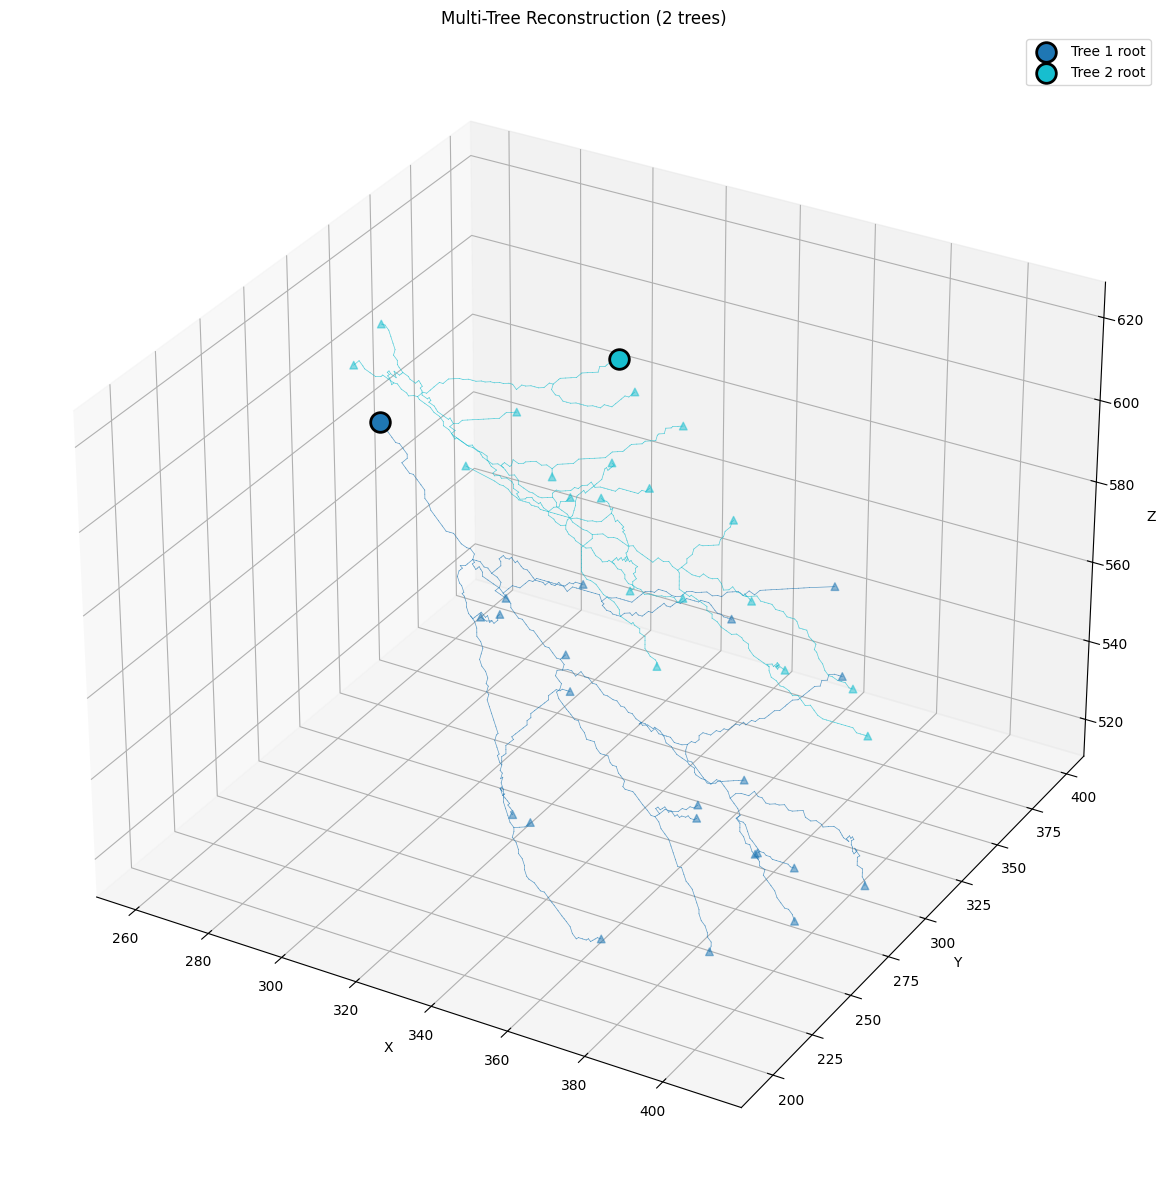

Tree 1 exported to hepatic_veins_tree1.json (669 branches)
Tree 2 exported to hepatic_veins_tree2.json (634 branches)


In [6]:
# Initialize reconstructor
reconstructor = VascularTreeReconstruction(
    thinning,
    gamma=3.0,
    mu=3.6e-3,
    Q_perf=0.125,
    P_out=60,
    P_in=100
)

# Run reconstruction
tree, root, radii, metrics = reconstructor.reconstruct(
    k_neighbors=8,
    n_candidates=500,
    optimize_bifurcations=True
)

# Visualize
# fig, ax = reconstructor.visualize_tree()
# plt.show()

reconstructor.export_tree_for_viewer('hepatic_vein_tree2.json')
print(tree)

reconstructor = MultiTreeReconstruction(
    thinning,
    n_trees=3,  # Expect 3 major hepatic veins
    gamma=3.0,
    mu=3.6e-3,
    Q_perf=0.125,
    P_out=60,
    P_in=100
)

# Extract multiple trees
trees = reconstructor.reconstruct_multiple_trees(
    k_neighbors_initial=5,      # Low k for separation
    k_neighbors_optimization=10, # Higher k for optimization
    min_tree_size=50,            # Minimum points per tree
    max_iterations=10            # Safety limit
)

# Print statistics
reconstructor.get_tree_statistics()

# Visualize all trees together
fig, ax = reconstructor.visualize_all_trees(show_remaining=True)
plt.show()

# Export for viewer
reconstructor.export_all_trees('hepatic_veins')



In [7]:
seg_thinning_medec, _ = sm.load_nii("../skeleton-viewer/data/hepaticvessel_001.nii.gz")
thinning_medec = load_thinning(seg_thinning_medec)

thinning_zenodo_path = "../zenodo_skeletons/Task08_HepaticVessel/skeletons/hepaticvessel_001_LNC.json"
thinning_zenodo = np.array(json.load(open(thinning_zenodo_path, 'r')))
# label_zenodo = sm.load_nii("../zenodo_skeletons/Task08_HepaticVessel/labelsTr/hepaticvessel_001_mod.nii.gz")[0]

reconstructor = MultiTreeReconstruction(
    thinning_zenodo,
    n_trees=3,
    gamma=3.0,
    mu=3.6e-3,
    Q_perf=0.125,
    P_out=60,
    P_in=100
)

reconstructor.reconstruct_multiple_trees(
    k_neighbors_initial=2,
    k_neighbors_optimization=8,
    min_tree_size=10,
    max_iterations=100
)

reconstructor.export_all_trees('hepatic_veins_zenodo')

Starting multi-tree reconstruction from 1432 points
Target: 3 trees

ITERATION 1: 1432 points remaining

Step 1: Building sparse graph (k=2)...
Step 2: Finding connected components...
  Found 34 components
  Largest component: 615 nodes
Step 3: Extracting subgraph with 615 points...
Step 4: Optimizing tree (k=8)...
Building graph from skeleton points...
Graph built: 615 nodes, 614 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 590
  Terminals: 34, Total nodes: 615
  Optimizing 33 bifurcations...
  Metrics: volume=0.01, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 276
  Terminals: 34, Total nodes: 615
  Optimizing 33 bifurcations...
  Metrics: volume=0.01, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 252
  Terminals: 34, Total nodes: 615
  Optimizing 33 bifurcations...
  Metrics: volume=0.01, murray_error=0.0000, radius_violations=0

Candidate 4/5: node 155
  Terminals: 34, 

In [8]:
save_skeleton(thinning_medec, "thinning_medec.json")

Skeleton saved to thinning_medec.json


In [9]:
thinning_zenodo_path = "../zenodo_skeletons/Task08_HepaticVessel/skeletons/hepaticvessel_001_LNC.json"
thinning_zenodo = np.array(json.load(open(thinning_zenodo_path, 'r')))

In [10]:
class RootSelectionStrategy:
    """
    Base class for root selection strategies
    """
    def __init__(self, name):
        self.name = name
    
    def select_candidates(self, graph, points, n_candidates=5):
        """
        Select root candidates from a graph
        
        Parameters:
        -----------
        graph : networkx.Graph
            Undirected graph of the tree
        points : np.array
            3D coordinates of points
        n_candidates : int
            Number of candidates to return
            
        Returns:
        --------
        candidates : list of int
            Node indices ranked by suitability
        """
        raise NotImplementedError


class SuperiorPositionStrategy(RootSelectionStrategy):
    """
    Select roots based on superior (highest Z) position
    Good for hepatic veins that drain upward
    """
    def __init__(self):
        super().__init__("Superior Position")
    
    def select_candidates(self, graph, points, n_candidates=5):
        # Get endpoints
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            # Fallback to all nodes
            endpoints = list(graph.nodes())
        
        # Sort by Z coordinate (highest first)
        endpoint_positions = points[endpoints]
        z_coords = endpoint_positions[:, 2]
        sorted_indices = np.argsort(z_coords)[::-1]  # Descending
        
        candidates = [endpoints[i] for i in sorted_indices[:n_candidates]]
        
        print(f"  [{self.name}] Top Z-coordinates: {z_coords[sorted_indices[:n_candidates]]}")
        
        return candidates


class InferiorPositionStrategy(RootSelectionStrategy):
    """
    Select roots based on inferior (lowest Z) position
    Good for portal veins that enter from below
    """
    def __init__(self):
        super().__init__("Inferior Position")
    
    def select_candidates(self, graph, points, n_candidates=5):
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            endpoints = list(graph.nodes())
        
        # Sort by Z coordinate (lowest first)
        endpoint_positions = points[endpoints]
        z_coords = endpoint_positions[:, 2]
        sorted_indices = np.argsort(z_coords)  # Ascending
        
        candidates = [endpoints[i] for i in sorted_indices[:n_candidates]]
        
        print(f"  [{self.name}] Bottom Z-coordinates: {z_coords[sorted_indices[:n_candidates]]}")
        
        return candidates


class CentralityStrategy(RootSelectionStrategy):
    """
    Select roots based on graph centrality measures
    Good for trees where root is topologically central
    """
    def __init__(self, centrality_type='closeness'):
        """
        Parameters:
        -----------
        centrality_type : str
            'closeness', 'betweenness', or 'eigenvector'
        """
        super().__init__(f"Centrality ({centrality_type})")
        self.centrality_type = centrality_type
    
    def select_candidates(self, graph, points, n_candidates=5):
        # Ensure graph is connected
        if not nx.is_connected(graph):
            largest_cc = max(nx.connected_components(graph), key=len)
            subgraph = graph.subgraph(largest_cc)
        else:
            subgraph = graph
        
        # Compute centrality
        if self.centrality_type == 'closeness':
            centrality = nx.closeness_centrality(subgraph)
        elif self.centrality_type == 'betweenness':
            centrality = nx.betweenness_centrality(subgraph)
        elif self.centrality_type == 'eigenvector':
            try:
                centrality = nx.eigenvector_centrality(subgraph, max_iter=1000)
            except:
                # Fallback to degree centrality
                centrality = nx.degree_centrality(subgraph)
        else:
            centrality = nx.degree_centrality(subgraph)
        
        # Get endpoints only
        endpoints = [n for n in subgraph.nodes() if subgraph.degree(n) == 1]
        
        if len(endpoints) == 0:
            endpoints = list(subgraph.nodes())
        
        # Sort by centrality
        endpoint_centrality = {n: centrality[n] for n in endpoints if n in centrality}
        sorted_nodes = sorted(endpoint_centrality, key=endpoint_centrality.get, reverse=True)
        
        candidates = sorted_nodes[:n_candidates]
        
        print(f"  [{self.name}] Top centralities: {[centrality[c] for c in candidates]}")
        
        return candidates


class LargestRadiusStrategy(RootSelectionStrategy):
    """
    Select roots based on local radius (from distance transform)
    Good for identifying main vessel entry points
    """
    def __init__(self):
        super().__init__("Largest Radius")
    
    def select_candidates(self, graph, points, n_candidates=5):
        # This requires distance transform data
        # For now, estimate from local point density
        
        from sklearn.neighbors import NearestNeighbors
        
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            endpoints = list(graph.nodes())
        
        # Estimate "radius" by average distance to k nearest neighbors
        k = min(10, len(points) - 1)
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(points)
        distances, _ = nbrs.kneighbors(points)
        
        # Average distance to neighbors (excluding self)
        avg_distances = distances[:, 1:].mean(axis=1)
        
        # Get endpoint radii
        endpoint_radii = [(n, avg_distances[n]) for n in endpoints]
        endpoint_radii.sort(key=lambda x: x[1], reverse=True)
        
        candidates = [n for n, _ in endpoint_radii[:n_candidates]]
        radii_values = [r for _, r in endpoint_radii[:n_candidates]]
        
        print(f"  [{self.name}] Top radii estimates: {radii_values}")
        
        return candidates


class SpatialRegionStrategy(RootSelectionStrategy):
    """
    Select roots based on spatial region (left/right/anterior/posterior)
    Good for anatomically separated structures
    """
    def __init__(self, region='superior', axis='z', percentile=90):
        """
        Parameters:
        -----------
        region : str
            'superior', 'inferior', 'left', 'right', 'anterior', 'posterior'
        axis : str
            'x', 'y', or 'z'
        percentile : float
            Percentile threshold (e.g., 90 = top 10%)
        """
        super().__init__(f"Spatial Region ({region})")
        self.region = region
        self.axis = axis
        self.percentile = percentile
        
        # Map region to axis and direction
        self.axis_map = {
            'superior': ('z', 'high'),
            'inferior': ('z', 'low'),
            'right': ('x', 'high'),
            'left': ('x', 'low'),
            'anterior': ('y', 'high'),
            'posterior': ('y', 'low')
        }
        
        if region in self.axis_map:
            self.axis, self.direction = self.axis_map[region]
    
    def select_candidates(self, graph, points, n_candidates=5):
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            endpoints = list(graph.nodes())
        
        # Get coordinates along specified axis
        axis_idx = {'x': 0, 'y': 1, 'z': 2}[self.axis]
        endpoint_positions = points[endpoints]
        coords = endpoint_positions[:, axis_idx]
        
        # Compute threshold
        if self.direction == 'high':
            threshold = np.percentile(coords, self.percentile)
            mask = coords >= threshold
        else:
            threshold = np.percentile(coords, 100 - self.percentile)
            mask = coords <= threshold
        
        # Filter endpoints
        filtered_endpoints = [endpoints[i] for i in np.where(mask)[0]]
        
        if len(filtered_endpoints) == 0:
            # Fallback: return top/bottom regardless of threshold
            sorted_indices = np.argsort(coords)
            if self.direction == 'high':
                sorted_indices = sorted_indices[::-1]
            filtered_endpoints = [endpoints[i] for i in sorted_indices[:n_candidates]]
        
        candidates = filtered_endpoints[:n_candidates]
        
        print(f"  [{self.name}] {len(filtered_endpoints)} candidates in region")
        print(f"  Threshold: {self.axis}={threshold:.2f}, direction={self.direction}")
        
        return candidates


class CompositeStrategy(RootSelectionStrategy):
    """
    Combine multiple strategies with weighted scoring
    """
    def __init__(self, strategies, weights=None):
        """
        Parameters:
        -----------
        strategies : list of RootSelectionStrategy
            List of strategies to combine
        weights : list of float (optional)
            Weight for each strategy (default: equal weights)
        """
        super().__init__("Composite")
        self.strategies = strategies
        self.weights = weights if weights else [1.0] * len(strategies)
    
    def select_candidates(self, graph, points, n_candidates=5):
        # Get candidates from each strategy
        all_candidates = {}
        
        for strategy, weight in zip(self.strategies, self.weights):
            candidates = strategy.select_candidates(graph, points, n_candidates=n_candidates*2)
            
            # Score based on rank (first = highest score)
            for rank, node in enumerate(candidates):
                score = (len(candidates) - rank) * weight
                if node in all_candidates:
                    all_candidates[node] += score
                else:
                    all_candidates[node] = score
        
        # Sort by combined score
        sorted_candidates = sorted(all_candidates.items(), key=lambda x: x[1], reverse=True)
        final_candidates = [node for node, score in sorted_candidates[:n_candidates]]
        
        print(f"  [{self.name}] Combined {len(self.strategies)} strategies")
        print(f"  Top scores: {[score for node, score in sorted_candidates[:n_candidates]]}")
        
        return final_candidates


class DistanceFromPreviousRootStrategy(RootSelectionStrategy):
    """
    Select roots that are far from previously selected roots
    Good for ensuring spatial separation between multiple trees
    """
    def __init__(self, previous_roots, previous_points):
        """
        Parameters:
        -----------
        previous_roots : list of int
            Indices of previously selected roots
        previous_points : np.array
            Point coordinates of previous trees
        """
        super().__init__("Distance from Previous")
        self.previous_roots = previous_roots
        self.previous_points = previous_points
    
    def select_candidates(self, graph, points, n_candidates=5):
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            endpoints = list(graph.nodes())
        
        # Compute distance from each endpoint to all previous roots
        endpoint_positions = points[endpoints]
        
        min_distances = []
        for ep_pos in endpoint_positions:
            # Find minimum distance to any previous root
            distances = [np.linalg.norm(ep_pos - self.previous_points[root]) 
                        for root in self.previous_roots]
            min_distances.append(min(distances) if distances else 0)
        
        # Sort by distance (farthest first)
        sorted_indices = np.argsort(min_distances)[::-1]
        candidates = [endpoints[i] for i in sorted_indices[:n_candidates]]
        
        top_distances = [min_distances[i] for i in sorted_indices[:n_candidates]]
        print(f"  [{self.name}] Distances from previous roots: {top_distances}")
        
        return candidates


# Modified MultiTreeReconstruction class
class MultiTreeReconstructionWithStrategies(MultiTreeReconstruction):
    """
    Extended version with configurable root selection strategies per tree
    """
    def __init__(self, skeleton_points, n_trees=3, strategies=None, **kwargs):
        """
        Parameters:
        -----------
        skeleton_points : np.array
            3D coordinates of skeleton points
        n_trees : int
            Expected number of trees
        strategies : list of RootSelectionStrategy (optional)
            One strategy per tree. If None, uses default strategy for all.
            Can also be a single strategy to use for all trees.
        **kwargs : dict
            Other parameters passed to MultiTreeReconstruction
        """
        super().__init__(skeleton_points, n_trees=n_trees, **kwargs)
        
        # Setup strategies
        if strategies is None:
            # Default: superior position for all trees
            self.strategies = [SuperiorPositionStrategy() for _ in range(n_trees)]
        elif isinstance(strategies, RootSelectionStrategy):
            # Single strategy for all trees
            self.strategies = [strategies for _ in range(n_trees)]
        else:
            # List of strategies
            self.strategies = strategies
            # Extend if not enough strategies
            while len(self.strategies) < n_trees:
                self.strategies.append(self.strategies[-1])
        
        self.previous_roots = []  # Track roots for distance-based strategies
    
    def _extract_single_tree_with_strategy(self, strategy, k_neighbors_initial, 
                                           k_neighbors_optimization, min_tree_size):
        """
        Extract one tree using a specific root selection strategy
        """
        if len(self.remaining_points) < min_tree_size:
            return None
        
        print(f"Step 1: Building sparse graph (k={k_neighbors_initial})...")
        sparse_graph = self._build_sparse_graph(self.remaining_points, k_neighbors_initial)
        
        if sparse_graph.number_of_edges() == 0:
            print("  No edges in sparse graph. Cannot extract tree.")
            return None
        
        print(f"Step 2: Finding connected components...")
        components = list(nx.connected_components(sparse_graph))
        print(f"  Found {len(components)} components")
        
        if len(components) == 0:
            return None
        
        largest_component = max(components, key=len)
        print(f"  Largest component: {len(largest_component)} nodes")
        
        if len(largest_component) < min_tree_size:
            print(f"  Component too small (< {min_tree_size}). Skipping.")
            return None
        
        component_indices = sorted(list(largest_component))
        component_points = self.remaining_points[component_indices]
        component_graph = sparse_graph.subgraph(largest_component).copy()
        
        print(f"Step 3: Selecting root using strategy: {strategy.name}")
        
        # Apply strategy to select root candidates
        candidates = strategy.select_candidates(component_graph, component_points, n_candidates=5)
        
        if len(candidates) == 0:
            print("  No candidates found. Using fallback.")
            candidates = [list(component_graph.nodes())[0]]
        
        print(f"  Testing {len(candidates)} root candidates...")
        
        # Optimize tree with standard CCO for each candidate
        best_tree_data = None
        best_score = float('inf')
        
        for cand_idx, root_candidate in enumerate(candidates):
            print(f"  Candidate {cand_idx+1}/{len(candidates)}: node {root_candidate}")
            
            try:
                reconstructor = VascularTreeReconstruction(
                    component_points,
                    gamma=self.gamma,
                    mu=self.mu,
                    Q_perf=self.Q_perf,
                    P_out=self.P_out,
                    P_in=self.P_in
                )
                
                # Manually set the root and skip candidate search
                tree = reconstructor.orient_tree_from_root(root_candidate)
                L, terminals = reconstructor.compute_tree_parameters(tree, root_candidate)
                radii, R, beta, rho = reconstructor.compute_radii(tree, root_candidate, L)
                
                # Optional: optimize bifurcations
                bifurcations = [n for n in tree.nodes() 
                               if tree.out_degree(n) == 2 and tree.in_degree(n) == 1]
                for bif in bifurcations[:min(5, len(bifurcations))]:
                    reconstructor.optimize_bifurcation(tree, bif, radii)
                
                radii, R, beta, rho = reconstructor.compute_radii(tree, root_candidate, L)
                metrics = reconstructor.compute_quality_metrics(tree, root_candidate, radii, L)
                
                # Compute score
                score = (metrics['total_volume'] / 1000 +
                        metrics['murray_error_mean'] * 100 +
                        metrics['radius_violations'] * 10)
                
                print(f"    Volume: {metrics['total_volume']:.2f}, Score: {score:.2f}")
                
                if score < best_score:
                    best_score = score
                    best_tree_data = {
                        'tree': tree,
                        'root': root_candidate,
                        'radii': radii,
                        'metrics': metrics,
                        'points': component_points,
                        'point_indices': self._get_original_indices(component_indices),
                        'reconstructor': reconstructor
                    }
            
            except Exception as e:
                print(f"    Failed: {e}")
                continue
        
        if best_tree_data:
            # Record this root for future distance-based strategies
            self.previous_roots.append(best_tree_data['root'])
        
        return best_tree_data
    
    def reconstruct_multiple_trees(self, k_neighbors_initial=5, k_neighbors_optimization=10,
                                   min_tree_size=50, max_iterations=10):
        """
        Extract multiple trees using different strategies
        """
        print(f"Starting multi-tree reconstruction from {len(self.original_points)} points")
        print(f"Target: {self.n_trees} trees with custom strategies\n")
        
        iteration = 0
        
        while len(self.remaining_points) >= min_tree_size and iteration < max_iterations:
            iteration += 1
            print(f"{'='*60}")
            print(f"ITERATION {iteration}: {len(self.remaining_points)} points remaining")
            print(f"{'='*60}\n")
            
            # Select strategy for this iteration
            if iteration - 1 < len(self.strategies):
                strategy = self.strategies[iteration - 1]
            else:
                strategy = self.strategies[-1]  # Use last strategy as default
            
            print(f"Using strategy: {strategy.name}\n")
            
            # Extract tree with this strategy
            tree_data = self._extract_single_tree_with_strategy(
                strategy,
                k_neighbors_initial=k_neighbors_initial,
                k_neighbors_optimization=k_neighbors_optimization,
                min_tree_size=min_tree_size
            )
            
            if tree_data is None:
                print("No more valid trees found. Stopping.")
                break
            
            self.trees.append(tree_data)
            self._remove_tree_points(tree_data)
            
            print(f"\n✓ Tree {iteration} extracted: {len(tree_data['point_indices'])} points")
            print(f"  Root at: {tree_data['points'][tree_data['root']]}")
            print(f"  Strategy: {strategy.name}")
            print(f"  Remaining points: {len(self.remaining_points)}\n")
            
            if len(self.trees) >= self.n_trees:
                print(f"Extracted target number of trees ({self.n_trees}). Stopping.")
                break
        
        print(f"\n{'='*60}")
        print(f"FINAL RESULT: {len(self.trees)} trees extracted")
        print(f"{'='*60}\n")
        
        return self.trees


# Usage examples
def example_hepatic_veins_reconstruction():
    """
    Example: Reconstruct 3 hepatic veins with appropriate strategies
    """
    # skeleton_points = np.load('hepatic_skeleton.npy')
    
    # Strategy 1: Right hepatic vein - superior position
    # Strategy 2: Middle hepatic vein - superior + central
    # Strategy 3: Left hepatic vein - superior + left region
    
    strategies = [
        SuperiorPositionStrategy(),
        CompositeStrategy([
            SuperiorPositionStrategy(),
            CentralityStrategy('closeness')
        ], weights=[2, 1]),
        CompositeStrategy([
            SuperiorPositionStrategy(),
            SpatialRegionStrategy('left')
        ], weights=[1, 2])
    ]
    
    reconstructor = MultiTreeReconstructionWithStrategies(
        thinning_zenodo_path,
        n_trees=3,
        strategies=strategies
    )
    
    trees = reconstructor.reconstruct_multiple_trees(
        k_neighbors_initial=5,
        k_neighbors_optimization=10,
        min_tree_size=50
    )
    
    reconstructor.visualize_all_trees()
    plt.show()
    
    reconstructor.export_all_trees('hepatic_veins')
    
    return reconstructor


def example_progressive_distance_strategy():
    """
    Example: Each new tree must be far from previous trees
    """
    # skeleton_points = np.load('hepatic_skeleton.npy')
    
    # First tree: superior position
    # Subsequent trees: far from previous + superior
    
    strategies = [
        SuperiorPositionStrategy()
    ]
    
    # Add distance-based strategies dynamically
    reconstructor = MultiTreeReconstructionWithStrategies(
        thinning_zenodo_path,
        n_trees=3,
        strategies=strategies
    )
    
    # Custom reconstruction loop with dynamic strategy updates
    iteration = 0
    while len(reconstructor.remaining_points) >= 50 and iteration < 3:
        iteration += 1
        
        if iteration == 1:
            strategy = SuperiorPositionStrategy()
        else:
            # Use distance from previous roots + superior position
            strategy = CompositeStrategy([
                DistanceFromPreviousRootStrategy(
                    reconstructor.previous_roots,
                    [t['points'] for t in reconstructor.trees]
                ),
                SuperiorPositionStrategy()
            ], weights=[3, 1])
        
        tree_data = reconstructor._extract_single_tree_with_strategy(
            strategy,
            k_neighbors_initial=5,
            k_neighbors_optimization=10,
            min_tree_size=50
        )
        
        if tree_data:
            reconstructor.trees.append(tree_data)
            reconstructor._remove_tree_points(tree_data)
    
    reconstructor.visualize_all_trees()
    plt.show()
    
    return reconstructor


def example_portal_and_hepatic_veins():
    """
    Example: Mixed anatomy - portal veins (inferior) + hepatic veins (superior)
    """
    # skeleton_points = np.load('liver_vessels.npy')
    
    strategies = [
        # Portal vein enters from below
        InferiorPositionStrategy(),
        # Hepatic veins drain from top
        SuperiorPositionStrategy(),
        SuperiorPositionStrategy()
    ]
    
    reconstructor = MultiTreeReconstructionWithStrategies(
        thinning_zenodo_path,
        n_trees=3,
        strategies=strategies
    )
    
    trees = reconstructor.reconstruct_multiple_trees()
    
    return reconstructor


def example_custom_strategy():
    """
    Example: Create a custom strategy for specific anatomy
    """
    class MedialRegionStrategy(RootSelectionStrategy):
        """
        Select roots near the midline (x ≈ 0)
        """
        def __init__(self):
            super().__init__("Medial Region")
        
        def select_candidates(self, graph, points, n_candidates=5):
            endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
            
            if len(endpoints) == 0:
                endpoints = list(graph.nodes())
            
            # Distance from midline (x=0 plane)
            endpoint_positions = points[endpoints]
            distances_from_midline = np.abs(endpoint_positions[:, 0])
            
            # Sort by distance (closest to midline first)
            sorted_indices = np.argsort(distances_from_midline)
            candidates = [endpoints[i] for i in sorted_indices[:n_candidates]]
            
            print(f"  [{self.name}] Distances from midline: {distances_from_midline[sorted_indices[:n_candidates]]}")
            
            return candidates
    
    # skeleton_points = np.load('hepatic_skeleton.npy')
    
    strategies = [
        MedialRegionStrategy(),  # Middle hepatic vein
        SpatialRegionStrategy('right'),  # Right hepatic vein
        SpatialRegionStrategy('left')   # Left hepatic vein
    ]
    
    reconstructor = MultiTreeReconstructionWithStrategies(
        thinning_zenodo_path,
        n_trees=3,
        strategies=strategies
    )
    
    trees = reconstructor.reconstruct_multiple_trees()
    
    return reconstructor


if __name__ == "__main__":
    # Run example
    reconstructor = example_hepatic_veins_reconstruction()

TypeError: len() of unsized object

In [13]:
import numpy as np
import networkx as nx
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json


class SimpleVascularReconstructor:
    """
    Simple, understandable vascular tree reconstruction
    
    This class takes skeleton points and builds realistic vascular trees
    with proper radii using CCO (Constrained Constructive Optimization) principles.
    """
    
    def __init__(self, points, gamma=3.0, mu=3.6e-3, Q_perf=0.125):
        """
        Initialize with skeleton points and physiological parameters
        
        Parameters:
        -----------
        points : numpy array, shape (N, 3)
            Your skeleton points as [[x, y, z], [x, y, z], ...]
        gamma : float
            Murray's law exponent (default 3.0)
        mu : float
            Blood viscosity in Pa·s (default 3.6e-3)
        Q_perf : float
            Flow per terminal in mL/min (default 0.125)
        """
        self.points = np.array(points, dtype=float)
        self.n_points = len(self.points)
        
        # Physiological parameters
        self.gamma = gamma
        self.mu = mu
        self.Q_perf = Q_perf / 60000  # Convert to mm³/s
        self.kappa = 8 * mu / np.pi
        
        # Pressure parameters
        P_in = 100 * 133.322   # mmHg to Pa
        P_out = 60 * 133.322
        self.xi = self.Q_perf / (P_in - P_out)
        
        print(f"Initialized with {self.n_points} skeleton points")
    
    def build_graph(self, k_neighbors=10):
        """
        Step 1: Build a connected graph from points
        
        Uses k-nearest neighbors + minimum spanning tree
        Returns a NetworkX graph
        """
        print(f"\nBuilding graph with k={k_neighbors} neighbors...")
        
        # Find k nearest neighbors for each point
        tree = cKDTree(self.points)
        
        # Build distance matrix
        n = self.n_points
        distances = np.full((n, n), np.inf)
        
        for i in range(n):
            dists, indices = tree.query(self.points[i], k=min(k_neighbors+1, n))
            for j, idx in enumerate(indices[1:]):  # Skip self
                distances[i, idx] = dists[j+1]
                distances[idx, i] = dists[j+1]  # Make symmetric
        
        # Build minimum spanning tree
        mst = minimum_spanning_tree(distances)
        
        # Convert to NetworkX graph
        G = nx.Graph()
        for i in range(n):
            G.add_node(i, pos=self.points[i])
        
        mst_coo = mst.tocoo()
        for i, j, weight in zip(mst_coo.row, mst_coo.col, mst_coo.data):
            G.add_edge(i, j, length=weight)
        
        print(f"  Created graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        
        # Check connectivity
        n_components = nx.number_connected_components(G)
        print(f"  Connected components: {n_components}")
        
        return G
    
    def find_root(self, graph, method='superior'):
        """
        Step 2: Find the best root node
        
        Methods:
        - 'superior': highest Z coordinate (for hepatic veins)
        - 'inferior': lowest Z coordinate (for portal veins)
        - 'central': most central node
        
        Returns the node index of the root
        """
        print(f"\nFinding root using '{method}' method...")
        
        # Get endpoint nodes (degree 1)
        endpoints = [n for n in graph.nodes() if graph.degree(n) == 1]
        
        if len(endpoints) == 0:
            print("  Warning: No endpoints found, using all nodes")
            endpoints = list(graph.nodes())
        
        print(f"  Evaluating {len(endpoints)} endpoint candidates")
        
        if method == 'superior':
            # Highest Z coordinate
            z_coords = [self.points[n][2] for n in endpoints]
            root = endpoints[np.argmax(z_coords)]
            print(f"  Selected root at Z={self.points[root][2]:.2f}")
        
        elif method == 'inferior':
            # Lowest Z coordinate
            z_coords = [self.points[n][2] for n in endpoints]
            root = endpoints[np.argmin(z_coords)]
            print(f"  Selected root at Z={self.points[root][2]:.2f}")
        
        elif method == 'central':
            # Most central node by closeness centrality
            if nx.is_connected(graph):
                centrality = nx.closeness_centrality(graph)
                endpoint_centrality = {n: centrality[n] for n in endpoints}
                root = max(endpoint_centrality, key=endpoint_centrality.get)
                print(f"  Selected root with centrality={centrality[root]:.3f}")
            else:
                # Fallback to superior
                print("  Graph disconnected, falling back to 'superior'")
                return self.find_root(graph, method='superior')
        
        else:
            raise ValueError(f"Unknown method: {method}")
        
        return root
    
    def orient_tree(self, graph, root):
        """
        Step 3: Convert undirected graph to directed tree from root
        
        Creates parent-child relationships with edges pointing away from root
        """
        print(f"\nOrienting tree from root node {root}...")
        
        # Create directed tree using BFS
        tree = nx.DiGraph()
        
        # Copy node positions
        for node in graph.nodes():
            tree.add_node(node, pos=self.points[node])
        
        # BFS to create directed edges
        visited = {root}
        queue = [root]
        
        while queue:
            current = queue.pop(0)
            for neighbor in graph.neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    # Add directed edge: parent -> child
                    tree.add_edge(current, neighbor, 
                                 length=graph[current][neighbor]['length'])
                    queue.append(neighbor)
        
        # Count terminals
        terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
        print(f"  Tree has {len(terminals)} terminal nodes")
        
        return tree
    
    def compute_radii(self, tree, root):
        """
        Step 4: Compute realistic radii for all segments using CCO
        
        This is the core CCO algorithm:
        1. Count terminals in each subtree (L_i)
        2. Compute hydraulic resistance (R_i) 
        3. Compute radius ratios (beta_i)
        4. Compute absolute radii
        
        Returns dictionary mapping node -> radius
        """
        print(f"\nComputing vessel radii using CCO...")
        
        # Count terminals in each subtree (bottom-up)
        L = {}  # Number of terminals per node
        
        def count_terminals(node):
            children = list(tree.successors(node))
            if len(children) == 0:  # Terminal node
                L[node] = 1
                return 1
            total = sum(count_terminals(child) for child in children)
            L[node] = total
            return total
        
        count_terminals(root)
        print(f"  Counted terminals in all subtrees")
        
        # Compute resistance and beta (bottom-up)
        R = {}    # Hydraulic resistance
        beta = {} # Radius ratio to parent
        
        def compute_resistance(node):
            children = list(tree.successors(node))
            parent = list(tree.predecessors(node))
            
            # Get segment length
            if parent:
                length = tree[parent[0]][node]['length']
            elif children:
                length = tree[node][children[0]]['length']
            else:
                length = 1.0
            
            if len(children) == 0:
                # Terminal: initialize resistance
                R[node] = self.kappa * length
                return R[node]
            
            # Compute children resistances first
            for child in children:
                compute_resistance(child)
            
            # Compute beta for each child
            if len(children) == 2:
                c1, c2 = children
                # Alpha ratio (Equation 4 from paper)
                alpha = ((L[c1] / L[node]) * (R[c1] / R[c2])) ** 0.25
                # Beta (Equation 3 from paper)
                beta[c1] = (1 + alpha ** self.gamma) ** (-1/self.gamma)
                beta[c2] = (1 + (1/alpha) ** self.gamma) ** (-1/self.gamma)
            else:
                for child in children:
                    beta[child] = 1.0
            
            # Compute resistance (Equation 6 from paper)
            sum_term = sum(beta[c]**4 / R[c] for c in children)
            R[node] = self.kappa * length + (1 / sum_term if sum_term > 0 else 0)
            
            return R[node]
        
        compute_resistance(root)
        print(f"  Computed resistance for all segments")
        
        # Compute absolute radii (top-down)
        radii = {}
        
        def compute_radii_recursive(node, parent_radius=None):
            if parent_radius is None:
                # Root radius (Equation 7 from paper)
                n_terminals = L[root]
                radii[node] = (self.xi * R[root] * n_terminals) ** 0.25
            else:
                # Child radius
                radii[node] = parent_radius * beta[node]
            
            # Recurse to children
            for child in tree.successors(node):
                compute_radii_recursive(child, radii[node])
        
        compute_radii_recursive(root)
        print(f"  Computed radii: [{min(radii.values()):.3f}, {max(radii.values()):.3f}] mm")
        
        return radii
    
    def save_tree(self, tree, radii, filename):
        """
        Save tree in JSON format for your viewer
        
        Format: [{"start": [x,y,z], "end": [x,y,z], "radius": r, "Q": q}, ...]
        """
        branches = []
        
        for parent, child in tree.edges():
            start_pos = self.points[parent].tolist()
            end_pos = self.points[child].tolist()
            radius = float(radii[child])
            Q = float(radius ** 3 * 100)  # Flow proportional to r³
            
            branch = {
                "start": start_pos,
                "end": end_pos,
                "radius": radius,
                "Q": Q
            }
            branches.append(branch)
        
        with open(filename, 'w') as f:
            json.dump(branches, f, indent=2)
        
        print(f"\nSaved tree to {filename} ({len(branches)} branches)")
    
    def reconstruct_single_tree(self, k_neighbors=10, root_method='superior', 
                               output_file='tree.json'):
        """
        Complete pipeline: points -> tree with radii
        
        This is the main function you call!
        
        Returns: (tree, root, radii)
        """
        print("="*60)
        print("SINGLE TREE RECONSTRUCTION")
        print("="*60)
        
        # Step 1: Build graph
        graph = self.build_graph(k_neighbors=k_neighbors)
        
        # Step 2: Find root
        root = self.find_root(graph, method=root_method)
        
        # Step 3: Orient tree
        tree = self.orient_tree(graph, root)
        
        # Step 4: Compute radii
        radii = self.compute_radii(tree, root)
        
        # Step 5: Save
        self.save_tree(tree, radii, output_file)
        
        print("="*60)
        print("RECONSTRUCTION COMPLETE")
        print("="*60)
        
        return tree, root, radii


class MultiTreeReconstructor:
    """
    Extract multiple independent trees from one point cloud
    
    Strategy: 
    1. Use low k to separate trees naturally
    2. Extract largest connected component
    3. Optimize that tree
    4. Remove its points
    5. Repeat
    """
    
    def __init__(self, points, gamma=3.0, mu=3.6e-3, Q_perf=0.125):
        """
        Initialize with skeleton points
        
        Parameters:
        -----------
        points : numpy array, shape (N, 3)
            All skeleton points
        """
        self.all_points = np.array(points, dtype=float)
        self.remaining_points = self.all_points.copy()
        self.remaining_indices = np.arange(len(self.all_points))
        
        self.gamma = gamma
        self.mu = mu
        self.Q_perf = Q_perf
        
        self.trees = []  # Stores extracted trees
        
        print(f"Initialized with {len(self.all_points)} total points")
    
    def extract_one_tree(self, k_sparse=5, k_optimize=10, root_method='superior'):
        """
        Extract one tree from remaining points
        
        Parameters:
        -----------
        k_sparse : int
            Low k for initial separation (helps find disconnected structures)
        k_optimize : int
            Higher k for optimizing the extracted tree
        root_method : str
            How to choose root ('superior', 'inferior', 'central')
        
        Returns:
        --------
        tree_data : dict or None
            Dictionary with tree info, or None if extraction failed
        """
        if len(self.remaining_points) < 20:
            print("Not enough points remaining")
            return None
        
        print(f"\n{'='*60}")
        print(f"EXTRACTING TREE FROM {len(self.remaining_points)} POINTS")
        print(f"{'='*60}")
        
        # Step 1: Build sparse graph to find connected components
        print(f"\nStep 1: Building sparse graph (k={k_sparse})...")
        reconstructor_sparse = SimpleVascularReconstructor(
            self.remaining_points, 
            gamma=self.gamma, 
            mu=self.mu, 
            Q_perf=self.Q_perf
        )
        sparse_graph = reconstructor_sparse.build_graph(k_neighbors=k_sparse)
        
        # Step 2: Get largest connected component
        print(f"\nStep 2: Finding largest component...")
        components = list(nx.connected_components(sparse_graph))
        
        if len(components) == 0:
            print("No components found")
            return None
        
        print(f"  Found {len(components)} components")
        component_sizes = [len(c) for c in components]
        print(f"  Component sizes: {sorted(component_sizes, reverse=True)[:5]}")
        
        largest_component = max(components, key=len)
        print(f"  Largest component: {len(largest_component)} nodes")
        
        if len(largest_component) < 20:
            print("  Component too small, skipping")
            return None
        
        # Step 3: Extract points from this component
        component_nodes = sorted(list(largest_component))
        component_points = self.remaining_points[component_nodes]
        
        print(f"\nStep 3: Optimizing tree with {len(component_points)} points...")
        
        # Step 4: Build optimized tree with higher k
        reconstructor = SimpleVascularReconstructor(
            component_points,
            gamma=self.gamma,
            mu=self.mu,
            Q_perf=self.Q_perf
        )
        
        graph = reconstructor.build_graph(k_neighbors=k_optimize)
        root = reconstructor.find_root(graph, method=root_method)
        tree = reconstructor.orient_tree(graph, root)
        radii = reconstructor.compute_radii(tree, root)
        
        # Step 5: Map back to original indices
        original_indices = self.remaining_indices[component_nodes]
        
        tree_data = {
            'tree': tree,
            'root': root,
            'radii': radii,
            'points': component_points,
            'original_indices': original_indices.tolist(),
            'n_points': len(component_points)
        }
        
        print(f"\n✓ Tree extracted successfully")
        print(f"  Root: node {root} at position {component_points[root]}")
        print(f"  Terminals: {sum(1 for n in tree.nodes() if tree.out_degree(n) == 0)}")
        
        return tree_data
    
    def remove_tree_points(self, tree_data):
        """
        Remove points belonging to extracted tree from remaining pool
        """
        # Find which remaining points to keep
        tree_points = tree_data['points']
        
        keep_mask = np.ones(len(self.remaining_points), dtype=bool)
        
        for i, point in enumerate(self.remaining_points):
            # Check if this point is in the tree
            distances = np.linalg.norm(tree_points - point, axis=1)
            if np.min(distances) < 0.01:  # Very close = same point
                keep_mask[i] = False
        
        # Update remaining
        self.remaining_points = self.remaining_points[keep_mask]
        self.remaining_indices = self.remaining_indices[keep_mask]
        
        print(f"  Removed {np.sum(~keep_mask)} points, {len(self.remaining_points)} remaining")
    
    def reconstruct_multiple_trees(self, n_trees=3, k_sparse=5, k_optimize=10, 
                                   root_methods=None):
        """
        Extract multiple trees
        
        Parameters:
        -----------
        n_trees : int
            How many trees to extract
        k_sparse : int
            Low k for separation
        k_optimize : int
            High k for optimization
        root_methods : list of str (optional)
            Root finding method for each tree
            If None, uses 'superior' for all
        
        Returns:
        --------
        trees : list of dict
            List of extracted trees
        """
        print("\n" + "="*60)
        print(f"MULTI-TREE RECONSTRUCTION: TARGET {n_trees} TREES")
        print("="*60)
        
        # Setup root methods
        if root_methods is None:
            root_methods = ['superior'] * n_trees
        elif isinstance(root_methods, str):
            root_methods = [root_methods] * n_trees
        
        # Extract trees one by one
        for i in range(n_trees):
            print(f"\n{'#'*60}")
            print(f"# TREE {i+1}/{n_trees}")
            print(f"{'#'*60}")
            
            if len(self.remaining_points) < 20:
                print("Not enough points remaining, stopping")
                break
            
            method = root_methods[i] if i < len(root_methods) else 'superior'
            
            tree_data = self.extract_one_tree(
                k_sparse=k_sparse,
                k_optimize=k_optimize,
                root_method=method
            )
            
            if tree_data is None:
                print("Failed to extract tree, stopping")
                break
            
            self.trees.append(tree_data)
            self.remove_tree_points(tree_data)
        
        print(f"\n{'='*60}")
        print(f"EXTRACTION COMPLETE: {len(self.trees)} TREES")
        print(f"{'='*60}")
        
        for i, tree_data in enumerate(self.trees):
            print(f"Tree {i+1}: {tree_data['n_points']} points")
        
        print(f"Unassigned: {len(self.remaining_points)} points")
        
        return self.trees
    
    def save_all_trees(self, base_filename='tree'):
        """
        Save all trees to separate JSON files
        
        Creates: tree_1.json, tree_2.json, tree_3.json, ...
        """
        for i, tree_data in enumerate(self.trees):
            filename = f"{base_filename}_{i+1}.json"
            
            branches = []
            tree = tree_data['tree']
            points = tree_data['points']
            radii = tree_data['radii']
            
            for parent, child in tree.edges():
                branch = {
                    "start": points[parent].tolist(),
                    "end": points[child].tolist(),
                    "radius": float(radii[child]),
                    "Q": float(radii[child] ** 3 * 100)
                }
                branches.append(branch)
            
            with open(filename, 'w') as f:
                json.dump(branches, f, indent=2)
            
            print(f"Saved {filename} ({len(branches)} branches)")
    
    def visualize(self):
        """
        Show all trees in 3D plot with different colors
        """
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        
        for i, tree_data in enumerate(self.trees):
            tree = tree_data['tree']
            points = tree_data['points']
            radii = tree_data['radii']
            root = tree_data['root']
            color = colors[i % len(colors)]
            
            # Draw branches
            for parent, child in tree.edges():
                p1 = points[parent]
                p2 = points[child]
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                       color=color, linewidth=2, alpha=0.7)
            
            # Mark root
            root_pos = points[root]
            ax.scatter(*root_pos, c=color, s=200, marker='o', 
                      edgecolors='black', linewidth=2, label=f'Tree {i+1}')
        
        # Show remaining points
        if len(self.remaining_points) > 0:
            ax.scatter(self.remaining_points[:, 0],
                      self.remaining_points[:, 1],
                      self.remaining_points[:, 2],
                      c='gray', s=5, alpha=0.3, label='Unassigned')
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend()
        ax.set_title(f'{len(self.trees)} Extracted Trees')
        
        plt.tight_layout()
        return fig, ax


In [14]:

# ============================================================================
# USAGE EXAMPLES
# ============================================================================

def example_single_tree():
    """
    Example 1: Reconstruct a single tree
    """
    # Load your points
    points = np.load('skeleton.npy')  # Or however you load them
    
    # Create reconstructor
    reconstructor = SimpleVascularReconstructor(points)
    
    # Reconstruct
    tree, root, radii = reconstructor.reconstruct_single_tree(
        k_neighbors=10,
        root_method='superior',  # or 'inferior' or 'central'
        output_file='my_tree.json'
    )
    
    return tree, root, radii


def example_multiple_trees():
    """
    Example 2: Extract 3 separate hepatic veins
    """
    # Load your points
    points = np.load('skeleton.npy')
    
    # Create multi-tree reconstructor
    reconstructor = MultiTreeReconstructor(points)
    
    # Extract 3 trees
    trees = reconstructor.reconstruct_multiple_trees(
        n_trees=3,
        k_sparse=5,      # Low k helps separate trees
        k_optimize=10,   # Higher k for optimization
        root_methods=['superior', 'superior', 'superior']  # All drain upward
    )
    
    # Save all trees
    reconstructor.save_all_trees('hepatic_vein')
    
    # Visualize
    reconstructor.visualize()
    plt.show()
    
    return reconstructor


def example_mixed_trees():
    """
    Example 3: Portal vein (enters below) + hepatic veins (exit above)
    """
    # points = np.load('skeleton.npy')
    
    reconstructor = MultiTreeReconstructor(thinning_zenodo_path)
    
    # First tree enters from below, others exit above
    trees = reconstructor.reconstruct_multiple_trees(
        n_trees=3,
        k_sparse=5,
        k_optimize=10,
        root_methods=['inferior', 'superior', 'superior']
    )
    
    reconstructor.save_all_trees('liver_vessels')
    reconstructor.visualize()
    plt.show()
    
    return reconstructor


def example_with_synthetic_data():
    """
    Example 4: Test with synthetic data (no file needed)
    """
    # Create 3 separate tree-like structures
    points = []
    
    # Tree 1: Right side
    for i in range(50):
        points.append([20 + i*0.5 + np.random.randn()*2, 
                      10 + i*0.3 + np.random.randn()*2, 
                      i + np.random.randn()*2])
    
    # Tree 2: Left side
    for i in range(50):
        points.append([-20 + i*0.5 + np.random.randn()*2, 
                      10 + i*0.3 + np.random.randn()*2, 
                      i + np.random.randn()*2])
    
    # Tree 3: Center
    for i in range(50):
        points.append([0 + i*0.3 + np.random.randn()*2, 
                      15 + i*0.4 + np.random.randn()*2, 
                      i + np.random.randn()*2])
    
    points = np.array(points)
    
    # Reconstruct
    reconstructor = MultiTreeReconstructor(points)
    trees = reconstructor.reconstruct_multiple_trees(n_trees=3, k_sparse=5)
    reconstructor.save_all_trees('synthetic_tree')
    reconstructor.visualize()
    plt.show()
    
    return reconstructor


# if __name__ == "__main__":
#     # Run synthetic example (works without any files!)
#     reconstructor = example_with_synthetic_data()

Initialized with 1432 total points

MULTI-TREE RECONSTRUCTION: TARGET 3 TREES

############################################################
# TREE 1/3
############################################################

EXTRACTING TREE FROM 1432 POINTS

Step 1: Building sparse graph (k=5)...
Initialized with 1432 skeleton points

Building graph with k=5 neighbors...
  Created graph: 1432 nodes, 1427 edges
  Connected components: 5

Step 2: Finding largest component...
  Found 5 components
  Component sizes: [1381, 24, 13, 7, 7]
  Largest component: 1381 nodes

Step 3: Optimizing tree with 1381 points...
Initialized with 1381 skeleton points

Building graph with k=10 neighbors...
  Created graph: 1381 nodes, 1380 edges
  Connected components: 1

Finding root using 'superior' method...
  Evaluating 116 endpoint candidates
  Selected root at Z=38.00

Orienting tree from root node 20...
  Tree has 115 terminal nodes

Computing vessel radii using CCO...
  Counted terminals in all subtrees
  Comput

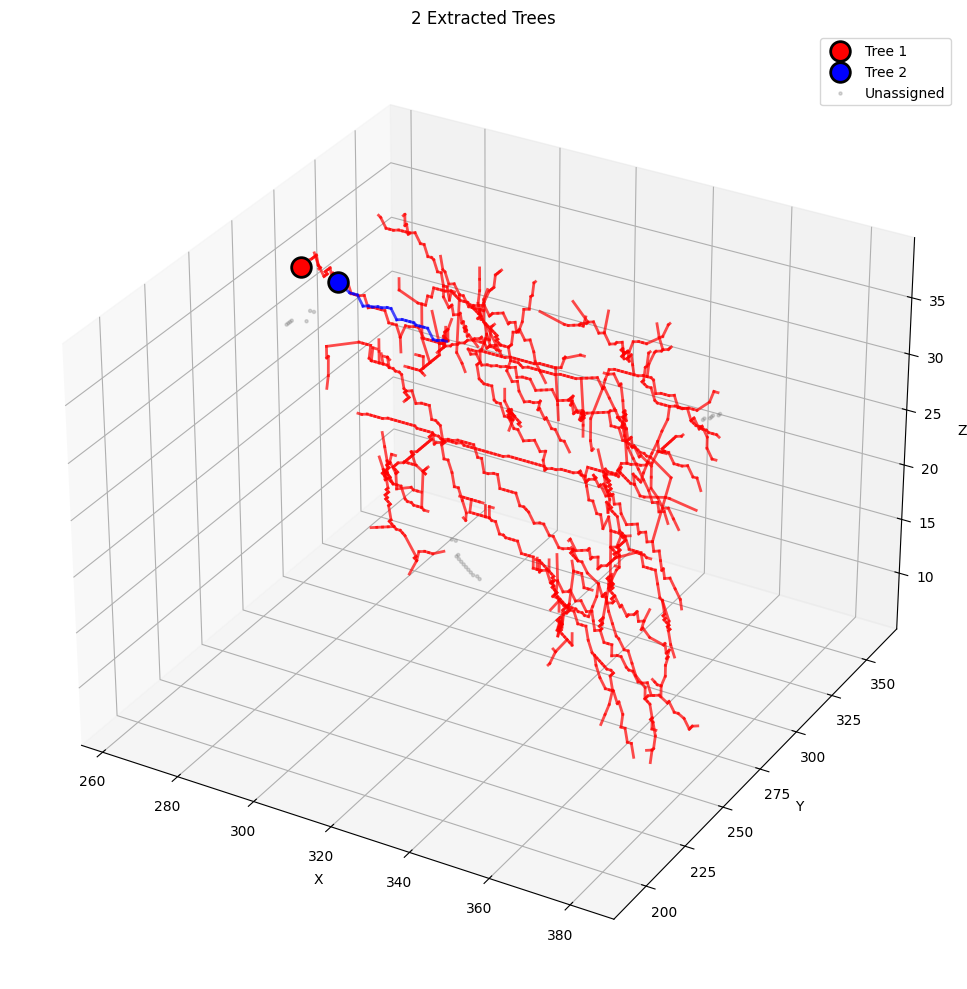

FileNotFoundError: [Errno 2] No such file or directory: 'data/thinning_zenodo_tree_1.json'

In [15]:
def reconstruct_zenodo():
    
    # Reconstruct
    reconstructor = MultiTreeReconstructor(thinning_zenodo)
    trees = reconstructor.reconstruct_multiple_trees(n_trees=3, k_sparse=5)
    reconstructor.save_all_trees('synthetic_tree')
    reconstructor.visualize()
    plt.show()
    
    return reconstructor

reconstructor = reconstruct_zenodo()
reconstructor.save_all_trees('data/thinning_zenodo_tree')